In [33]:
from langgraph.graph import START, END, StateGraph
from dotenv import load_dotenv

In [34]:
load_dotenv()

True

In [35]:
from langchain_openai import AzureChatOpenAI
import os

In [36]:
client = AzureChatOpenAI(
    api_key = os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    azure_endpoint= os.getenv("AZURE_OPENAI_ENDPOINT"),
)

In [37]:
from langchain.messages import HumanMessage, SystemMessage

In [38]:
from langchain_groq import ChatGroq

In [ ]:
groq = ChatGroq(
    api_key = os.getenv("GROQ_API_KEY"),
    model = "openai/gpt-oss-120b"

)

In [40]:
groq.invoke("hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "hello". We should greet them. Possibly ask how can help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 72, 'total_tokens': 120, 'completion_time': 0.100398002, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.00920621, 'prompt_tokens_details': None, 'queue_time': 0.369357237, 'total_time': 0.109604212}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c868cf1eaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06c5d-0fe0-74b0-aaf7-ef9327df130f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 48, 'total_tokens': 120, 'output_token_details': {'reasoning': 30}})

In [41]:
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [42]:
client_with_tools = client.bind_tools([add])

In [43]:
client_with_tools.invoke("What's 2+2")

AIMessage(content='2 + 2 = 4', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 149, 'total_tokens': 166, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 0, 'engine_ttft_ms': 309, 'engine_ttlt_ms': 311, 'pre_inference_ms': 270, 'service_tbt_ms': 3, 'service_ttft_ms': 815, 'service_ttlt_ms': 871, 'user_visible_ttft_ms': 545}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-EKNCG32TLmNzKNk9v7xS8EmfeZSzV', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severi

In [44]:
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class State(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]

In [45]:
def llm_tool(state: State):
    return {"messages": [client_with_tools.invoke(state.messages)]}

In [46]:
from IPython.display import Image, display
graph = StateGraph(State)

graph.add_node("llm_tool", llm_tool)

graph.add_edge(START, "llm_tool")
graph.add_edge("llm_tool", END)

graph_builder = graph.compile()

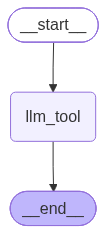

In [47]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [48]:
result = graph_builder.invoke({"messages": ["What's 2+2"]})

In [49]:
from pprint import pprint

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's 2+2
================================== Ai Message ==================================

2 + 2 = 4.


In [50]:
from langgraph.prebuilt import ToolNode, tools_condition

In [51]:
tools = [add]

In [52]:
builder=StateGraph(State)

## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


graph_builder = builder.compile()


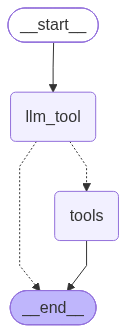

In [54]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [55]:
## invocation

messages=graph_builder.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================

2 plus 2 is 4.
